In [174]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [175]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [176]:
df_diamonds_raw = sns.load_dataset('diamonds')

In [177]:
df_diamonds = df_diamonds_raw.copy()

In [178]:
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


Text(0, 0.5, 'y, цена')

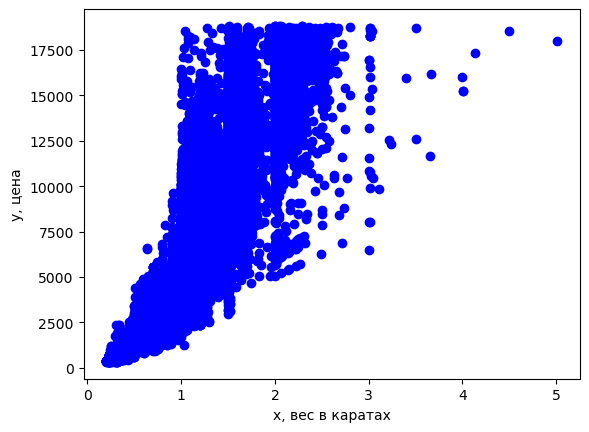

In [179]:
x = df_diamonds['carat']
y = df_diamonds['price']
plt.scatter(x, y, color="blue")
plt.xlabel('x, вес в каратах')
plt.ylabel('y, цена')

In [180]:
# Проверяем корреляцию price и carat
corr = df_diamonds['carat'].corr(df_diamonds['price'])
print(f'{corr:.4f}')

0.9216


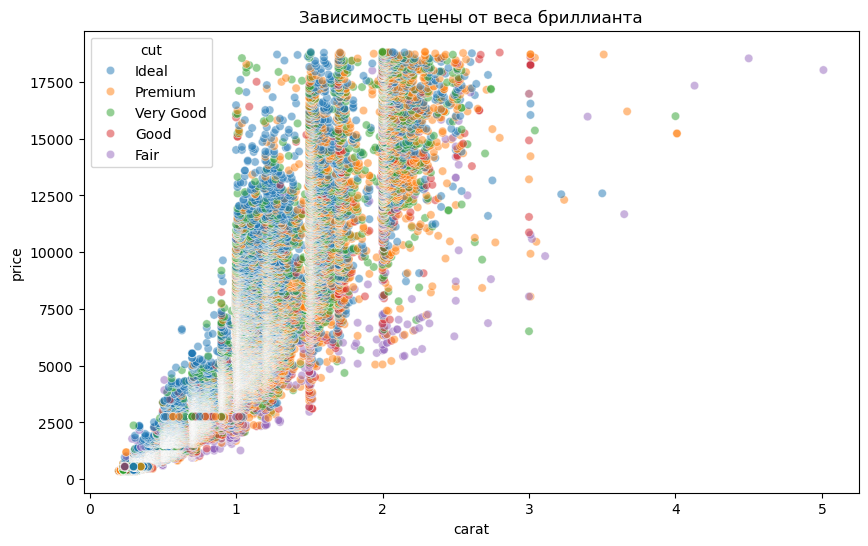

In [181]:
# Проверяем корреляцию на графике
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_diamonds, x='carat', y='price', alpha=0.5, hue='cut')
plt.title('Зависимость цены от веса бриллианта')
plt.show()

In [182]:
df_diamonds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [183]:
# Строим тепловую карту корреляции
# Выбираем только числовые колонки
numeric_df = df_diamonds.select_dtypes(include=['float64', 'int64'])

In [184]:
# Считаем матрицу корреляции для всех чисел
corr_matrix = numeric_df.corr()

Text(0.5, 1.0, 'Матрица корреляции всех признаков')

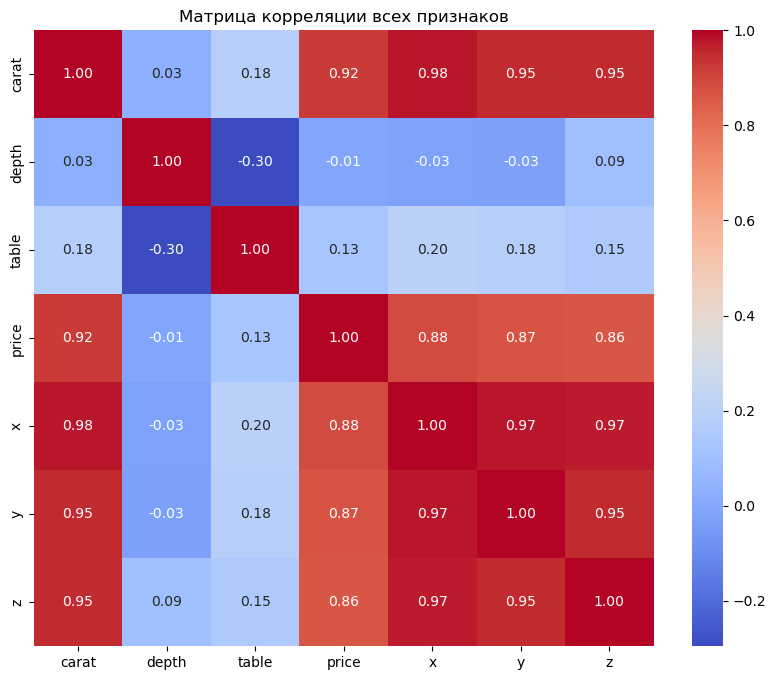

In [185]:
# Рисуем тепловую карту
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляции всех признаков')

In [186]:
# Убираем лишние признаки, которые также коррелируют с ценой
df_diamonds_dropped = df_diamonds.drop(['x', 'y', 'z', 'depth', 'table'], axis=1)
df_diamonds_dropped

,carat,cut,color,clarity,price
0,0.23,Ideal,E,SI2,326
1,0.21,Premium,E,SI1,326
2,0.23,Good,E,VS1,327
3,0.29,Premium,I,VS2,334
4,0.31,Good,J,SI2,335
...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,2757
53936,0.72,Good,D,SI1,2757
53937,0.70,Very Good,D,SI1,2757
53938,0.86,Premium,H,SI2,2757


In [187]:
# Разделяем X и y
X_raw = df_diamonds_dropped.drop('price', axis=1)
X = pd.get_dummies(X_raw, drop_first=True)
y = df_diamonds_dropped['price']

In [188]:
# Разделение train_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((43152, 18), (10788, 18), (43152,), (10788,))

In [189]:
# Нормализация
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [190]:
# Создаем и обучаем модель
model = LinearRegression()

In [191]:
# Обучаем
model.fit(X_train_scaled, y_train)

LinearRegression()

In [192]:
# Проверяем точность модели по индексу R2
predictions = model.predict(X_test_scaled)
model_score = r2_score(y_test, predictions)
print(f'Точность модели R2: {model_score:.2f}')

Точность модели R2: 0.92


In [193]:
# Смотрим, на сколько именно ошиблась модель.
# В регрессии для этого используют MAE (Mean Absolute Error)
# — она показывает среднюю ошибку в «реальных деньгах».
mae = mean_absolute_error(y_test, predictions)
print(f'Средняя ошибка: {mae:.2f}$')

Средняя ошибка: 802.12$


In [2]:
pwd

'C:\\Users\\Sergey\\jupiter_projects\\ml_learning_projects'